# EfficientNet-B0 With Simple Data Augmentation

This notebook trains only the EfficientNet-B0 segmentation baseline with simple data augmentation. It is intended as an intermediate experiment between the plain baseline models and the later paper-inspired EfficientNet U-Net model.

The workflow follows the baseline notebook rules: the fixed train/validation/test split is reused, the best checkpoint is selected by validation mIoU, the official test set is evaluated only once after training, and the best model is saved under `Best_Model/`.


## 1. Setup and Imports

This section imports the libraries used by the experiment. The torchvision model cache is redirected to the project folder, and `tqdm.std` is used so progress bars render as plain text rather than Jupyter widgets in VS Code/Colab.


In [10]:
import json
import os
import random
from pathlib import Path

TORCH_CACHE_DIR = Path.cwd().resolve() / "Torch_Model_Cache"
os.environ["TORCH_HOME"] = str(TORCH_CACHE_DIR)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageEnhance
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.std import tqdm

from google.colab import drive

print("PyTorch:", torch.__version__)
print("Torch model cache:", TORCH_CACHE_DIR)
print(
    "Available device:",
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu",
)


PyTorch: 2.11.0+cu128
Torch model cache: /content/Torch_Model_Cache
Available device: cuda


---
## 2. Fixed Values and Paths

This section defines the shared constants. `BATCH_SIZE` and `MAX_EPOCHS` match the merged baseline setup. The path block first tries the current folder, then a common Google Drive Colab path, so the notebook can be used both locally and from a Colab-connected VS Code kernel.


In [11]:
drive.mount("/content/drive")

CANDIDATE_ROOTS = [
    Path.cwd().resolve(),
    Path("/content/drive/MyDrive/COMP9444/9444"),
    Path("/content/9444"),
]

ROOT = next(
    (
        root for root in CANDIDATE_ROOTS
        if (root / "UECFOODPIX" / "data").exists()
        and (root / "uecfoodpix_split_train3000_val500.json").exists()
    ),
    None,
)
if ROOT is None:
    searched = "\n".join(str(root) for root in CANDIDATE_ROOTS)
    raise FileNotFoundError(
        "Could not find UECFOODPIX/data and uecfoodpix_split_train3000_val500.json. "
        + "Searched:\n"
        + searched
    )

DATA_ROOT = ROOT / "UECFOODPIX" / "data"
SPLIT_FILE = ROOT / "uecfoodpix_split_train3000_val500.json"
BEST_MODEL_DIR = ROOT / "Best_Model"

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
MAX_EPOCHS = 25
SEED = 9444
NUM_WORKERS = 0

BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {ROOT}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Split file: {SPLIT_FILE}")
print(f"Best model folder: {BEST_MODEL_DIR}")
print(f"Input size: {WIDTH} x {HEIGHT}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {MAX_EPOCHS}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/COMP9444/9444
Dataset root: /content/drive/MyDrive/COMP9444/9444/UECFOODPIX/data
Split file: /content/drive/MyDrive/COMP9444/9444/uecfoodpix_split_train3000_val500.json
Best model folder: /content/drive/MyDrive/COMP9444/9444/Best_Model
Input size: 384 x 320
Batch size: 16
Max epochs: 25


---
## 3. Fixed Split

The same 3,000/500 split from the baseline experiments is used here. The 1,000 official test images are kept separate and are not used for model selection.


In [12]:
def load_split(split_file):
    split_data = json.loads(Path(split_file).read_text(encoding="utf-8"))
    train_ids = [str(item) for item in split_data["train_ids"]]
    val_ids = [str(item) for item in split_data["val_ids"]]

    assert len(train_ids) == split_data["train_size"]
    assert len(val_ids) == split_data["val_size"]
    assert len(train_ids) == len(set(train_ids))
    assert len(val_ids) == len(set(val_ids))
    assert not (set(train_ids) & set(val_ids))
    return train_ids, val_ids, split_data


def load_test_ids(data_root):
    return [
        item.strip()
        for item in (Path(data_root) / "test1000.txt").read_text().splitlines()
        if item.strip()
    ]


train_ids, val_ids, split_info = load_split(SPLIT_FILE)
test_ids = load_test_ids(DATA_ROOT)

print("Training images:", len(train_ids))
print("Validation images:", len(val_ids))
print("Test images:", len(test_ids))
print("Train/validation overlap:", len(set(train_ids) & set(val_ids)))
print("Split seeds:", split_info["train_seed"], split_info["val_seed"])


Training images: 3000
Validation images: 500
Test images: 1000
Train/validation overlap: 0
Split seeds: 9444 9445


---
## 4. Dataset and Simple Data Augmentation

Training images use synchronized geometric augmentation for the image and mask, plus color augmentation for the image only. Validation and test images are only resized and normalized.

Augmentations used:

1. Random horizontal flip.
2. Small random rotation.
3. Random resized crop with mild scale/aspect changes.
4. Mild brightness, contrast and saturation jitter.


In [13]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


AUGMENTATION_CONFIG = {
    "horizontal_flip_prob": 0.5,
    "rotation_degrees": 10,
    "crop_scale_min": 0.85,
    "crop_scale_max": 1.0,
    "aspect_min": 0.9,
    "aspect_max": 1.1,
    "brightness": 0.15,
    "contrast": 0.15,
    "saturation": 0.12,
}


def load_categories(category_file):
    rows = Path(category_file).read_text(encoding="utf-8", errors="replace").splitlines()
    categories = ["background"]
    for row in rows[1:]:
        fields = row.strip().split(maxsplit=1)
        if len(fields) == 2:
            categories.append(fields[1])
    assert len(categories) == NUM_CLASSES
    return categories


def random_factor(strength):
    return 1.0 + random.uniform(-strength, strength)


def apply_color_jitter(image, config):
    image = ImageEnhance.Brightness(image).enhance(random_factor(config["brightness"]))
    image = ImageEnhance.Contrast(image).enhance(random_factor(config["contrast"]))
    image = ImageEnhance.Color(image).enhance(random_factor(config["saturation"]))
    return image


def random_resized_crop_pair(image, mask, config):
    width, height = image.size
    area = width * height
    for _ in range(10):
        target_area = area * random.uniform(config["crop_scale_min"], config["crop_scale_max"])
        aspect = random.uniform(config["aspect_min"], config["aspect_max"])
        crop_width = int(round((target_area * aspect) ** 0.5))
        crop_height = int(round((target_area / aspect) ** 0.5))
        if 0 < crop_width <= width and 0 < crop_height <= height:
            left = random.randint(0, width - crop_width)
            top = random.randint(0, height - crop_height)
            box = (left, top, left + crop_width, top + crop_height)
            return image.crop(box), mask.crop(box)
    return image, mask


def apply_train_augmentation(image, mask, config):
    if random.random() < config["horizontal_flip_prob"]:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    angle = random.uniform(-config["rotation_degrees"], config["rotation_degrees"])
    image = image.rotate(angle, resample=Image.Resampling.BILINEAR, fillcolor=(0, 0, 0))
    mask = mask.rotate(angle, resample=Image.Resampling.NEAREST, fillcolor=0)

    image, mask = random_resized_crop_pair(image, mask, config)
    image = apply_color_jitter(image, config)
    return image, mask


class FoodSegmentationDataset(Dataset):
    def __init__(self, root, ids, split, augment, width, height, augmentation_config=None):
        self.root = Path(root)
        self.ids = list(ids)
        self.split = split
        self.augment = augment
        self.width = width
        self.height = height
        self.augmentation_config = augmentation_config or AUGMENTATION_CONFIG
        self.image_dir = self.root / "UECFoodPIX" / split / "img"
        self.mask_dir = self.root / "UECFoodPIX" / split / "mask"

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        sample_id = self.ids[index]
        image_path = self.image_dir / f"{sample_id}.jpg"
        mask_path = self.mask_dir / f"{sample_id}.png"

        with Image.open(image_path) as raw_image:
            image = raw_image.convert("RGB")
        with Image.open(mask_path) as raw_mask:
            mask = raw_mask.copy()

        if self.augment:
            image, mask = apply_train_augmentation(image, mask, self.augmentation_config)

        image = image.resize((self.width, self.height), Image.Resampling.BILINEAR)
        mask = mask.resize((self.width, self.height), Image.Resampling.NEAREST)

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array.copy()).permute(2, 0, 1)
        image_tensor = (image_tensor - IMAGENET_MEAN) / IMAGENET_STD

        mask_array = np.asarray(mask)
        if mask_array.ndim == 3:
            mask_array = mask_array[..., 0]
        mask_tensor = torch.from_numpy(mask_array.astype(np.int64, copy=True)).long()
        return image_tensor, mask_tensor


categories = load_categories(DATA_ROOT / "category.txt")
train_dataset = FoodSegmentationDataset(
    DATA_ROOT, train_ids, "train", True, WIDTH, HEIGHT, AUGMENTATION_CONFIG
)
val_dataset = FoodSegmentationDataset(DATA_ROOT, val_ids, "train", False, WIDTH, HEIGHT)
test_dataset = FoodSegmentationDataset(DATA_ROOT, test_ids, "test", False, WIDTH, HEIGHT)

x_sample, y_sample = val_dataset[0]
print("Image tensor:", tuple(x_sample.shape))
print("Mask tensor:", tuple(y_sample.shape))
print("Sample mask label range:", int(y_sample.min()), "to", int(y_sample.max()))
print("Categories including background:", len(categories))
print("Augmentation config:", AUGMENTATION_CONFIG)


Image tensor: (3, 320, 384)
Mask tensor: (320, 384)
Sample mask label range: 0 to 99
Categories including background: 103
Augmentation config: {'horizontal_flip_prob': 0.5, 'rotation_degrees': 10, 'crop_scale_min': 0.85, 'crop_scale_max': 1.0, 'aspect_min': 0.9, 'aspect_max': 1.1, 'brightness': 0.15, 'contrast': 0.15, 'saturation': 0.12}


---
## 5. Metrics, Plotting and Training Utilities

This section is shared by the EfficientNet augmentation experiment. Validation mIoU is the selection metric. The best model is saved during training, then the selected checkpoint is loaded and evaluated once on the test set.


In [14]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )


def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def update_confusion(confusion, prediction, target):
    prediction = prediction.detach().reshape(-1).cpu().to(torch.int64)
    target = target.detach().reshape(-1).cpu().to(torch.int64)
    valid = (target >= 0) & (target < NUM_CLASSES)
    encoded = target[valid] * NUM_CLASSES + prediction[valid].clamp(0, NUM_CLASSES - 1)
    confusion += torch.bincount(encoded, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)


def confusion_statistics(confusion):
    cm = confusion.double().cpu()
    tp = cm.diag()
    support = cm.sum(1)
    predicted = cm.sum(0)
    union = support + predicted - tp
    valid_iou = union > 0

    per_class_iou = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    per_class_iou[valid_iou] = tp[valid_iou] / union[valid_iou]
    pixel_accuracy = float(tp.sum() / cm.sum().clamp_min(1))
    mean_iou = float(per_class_iou[valid_iou].mean()) if valid_iou.any() else 0.0
    return {
        "pixel_accuracy": pixel_accuracy,
        "mean_iou": mean_iou,
        "per_class_iou": per_class_iou,
        "support": support,
    }


def run_epoch(model, loader, loss_fn, device, optimizer=None, phase="train"):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
    context = torch.enable_grad() if training else torch.no_grad()

    progress = tqdm(
        loader,
        desc=phase,
        leave=False,
        dynamic_ncols=False,
        ascii=True,
        bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]",
    )
    with context:
        for images, masks in progress:
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            loss = loss_fn(logits, masks)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.shape[0]
            update_confusion(confusion, logits.argmax(1), masks)

    stats = confusion_statistics(confusion)
    return total_loss / len(loader.dataset), stats, confusion


def plot_training_history(history, model_name):
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, [row["train_loss"] for row in history], label="Train loss")
    axes[0].plot(epochs, [row["val_loss"] for row in history], label="Validation loss")
    axes[0].set(title=f"{model_name}: Training and Validation Loss", xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_accuracy"] for row in history], label="Train pixel accuracy")
    axes[1].plot(epochs, [row["val_accuracy"] for row in history], label="Validation pixel accuracy")
    axes[1].plot(epochs, [row["train_miou"] for row in history], label="Train mIoU")
    axes[1].plot(epochs, [row["val_miou"] for row in history], label="Validation mIoU")
    axes[1].set(title=f"{model_name}: Accuracy and mIoU", xlabel="Epoch", ylabel="Score", ylim=(0, 1))
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()


def normalized_confusion(confusion):
    cm = confusion.detach().cpu().numpy().astype(np.float64)
    return cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)


def plot_overall_confusion(confusion, title):
    normalized = normalized_confusion(confusion)
    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class id")
    ax.set_ylabel("True class id")
    ticks = np.arange(0, NUM_CLASSES, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_class_subset_heatmap(confusion, class_indices, title):
    normalized = normalized_confusion(confusion)
    subset = normalized[np.ix_(class_indices, class_indices)]
    labels = [categories[index] for index in class_indices]

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(subset, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=70, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(labels)), labels=labels, fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def best_worst_class_indices(confusion, top_k=10):
    stats = confusion_statistics(confusion)
    per_class_iou = stats["per_class_iou"]
    support = stats["support"]
    valid = support > 0
    valid[0] = False
    valid_indices = torch.where(valid)[0]
    ordered = valid_indices[torch.argsort(per_class_iou[valid_indices])]
    worst = ordered[:top_k].tolist()
    best = torch.flip(ordered[-top_k:], dims=[0]).tolist()
    return best, worst, stats


def print_class_iou_table(title, indices, per_class_iou, support):
    print(title)
    for index in indices:
        print(f"{index:3d} {categories[index]:30s} IoU={float(per_class_iou[index]):.4f} support={int(support[index])}")


def plot_best_worst_heatmaps(confusion, model_name):
    best, worst, stats = best_worst_class_indices(confusion, top_k=10)
    print_class_iou_table("Best 10 classes by test IoU", best, stats["per_class_iou"], stats["support"])
    print_class_iou_table("Worst 10 classes by test IoU", worst, stats["per_class_iou"], stats["support"])
    plot_class_subset_heatmap(confusion, best, f"{model_name}: Best 10 classes test heatmap")
    plot_class_subset_heatmap(confusion, worst, f"{model_name}: Worst 10 classes test heatmap")


---
## 6. EfficientNet-B0 Augmentation Experiment

This section defines and trains the augmented EfficientNet-B0 baseline. It uses the same FCN-style segmentation head as the baseline, while the dataset applies the simple augmentations from Section 4 during training.


Training EfficientNet-B0 + Simple Augmentation
Config: {'learning_rate': 0.0002, 'weight_decay': 0.0005, 'dropout': 0.25, 'early_stopping_patience': 5, 'scheduler_patience': 2, 'lr_factor': 0.5, 'pretrained': True}
Checkpoint: /content/drive/MyDrive/COMP9444/9444/Best_Model/EfficientNetB0_Augmented_best_model.pt


{'epoch': 1, 'train_loss': 2.4590300079981486, 'val_loss': 1.653114411354065, 'train_accuracy': 0.5273582763671875, 'train_miou': 0.031090041894268363, 'val_accuracy': 0.651620947265625, 'val_miou': 0.11075399852858808, 'learning_rate': 0.0002}
Saved new best model: val_mIoU=0.1108


{'epoch': 2, 'train_loss': 1.4719006706873576, 'val_loss': 1.1313076062202454, 'train_accuracy': 0.6643219156901041, 'train_miou': 0.14896859303369833, 'val_accuracy': 0.7196748046875, 'val_miou': 0.26344808843156065, 'learning_rate': 0.0002}
Saved new best model: val_mIoU=0.2634


{'epoch': 3, 'train_loss': 1.1073885656992595, 'val_loss': 0.9518262934684754, 'train_accuracy': 0.7216123453776042, 'train_miou': 0.27224566153491725, 'val_accuracy': 0.746934521484375, 'val_miou': 0.33120429863751066, 'learning_rate': 0.0002}
Saved new best model: val_mIoU=0.3312


{'epoch': 4, 'train_loss': 0.8803191367785136, 'val_loss': 0.8476965641975402, 'train_accuracy': 0.7652064208984375, 'train_miou': 0.3750916326673584, 'val_accuracy': 0.7679533528645833, 'val_miou': 0.387615259463768, 'learning_rate': 0.0002}
Saved new best model: val_mIoU=0.3876


...

{'epoch': 21, 'train_loss': 0.17896469541390736, 'val_loss': 0.7296469695568085, 'train_accuracy': 0.9371936360677083, 'train_miou': 0.8558740100512212, 'val_accuracy': 0.8055779622395833, 'val_miou': 0.4942797092312358, 'learning_rate': 0.0001}


{'epoch': 22, 'train_loss': 0.17496552447477975, 'val_loss': 0.7542615141868592, 'train_accuracy': 0.9382989501953125, 'train_miou': 0.8585924371187708, 'val_accuracy': 0.8036607259114583, 'val_miou': 0.4923210715426675, 'learning_rate': 0.0001}


{'epoch': 23, 'train_loss': 0.17758338872591656, 'val_loss': 0.757483286857605, 'train_accuracy': 0.9377174289279514, 'train_miou': 0.8549838277217829, 'val_accuracy': 0.805810888671875, 'val_miou': 0.49427346244628295, 'learning_rate': 5e-05}


{'epoch': 24, 'train_loss': 0.16685945959885914, 'val_loss': 0.7534475345611572, 'train_accuracy': 0.9410027940538195, 'train_miou': 0.8636706434817997, 'val_accuracy': 0.8058392903645833, 'val_miou': 0.49672807885477066, 'learning_rate': 5e-05}


{'epoch': 25, 'train_loss': 0.15749206960201265, 'val_loss': 0.7405125617980957, 'train_accuracy': 0.9434180257161459, 'train_miou': 0.871446765189114, 'val_accuracy': 0.8064661295572917, 'val_miou': 0.49999927409286254, 'learning_rate': 5e-05}
Saved new best model: val_mIoU=0.5000


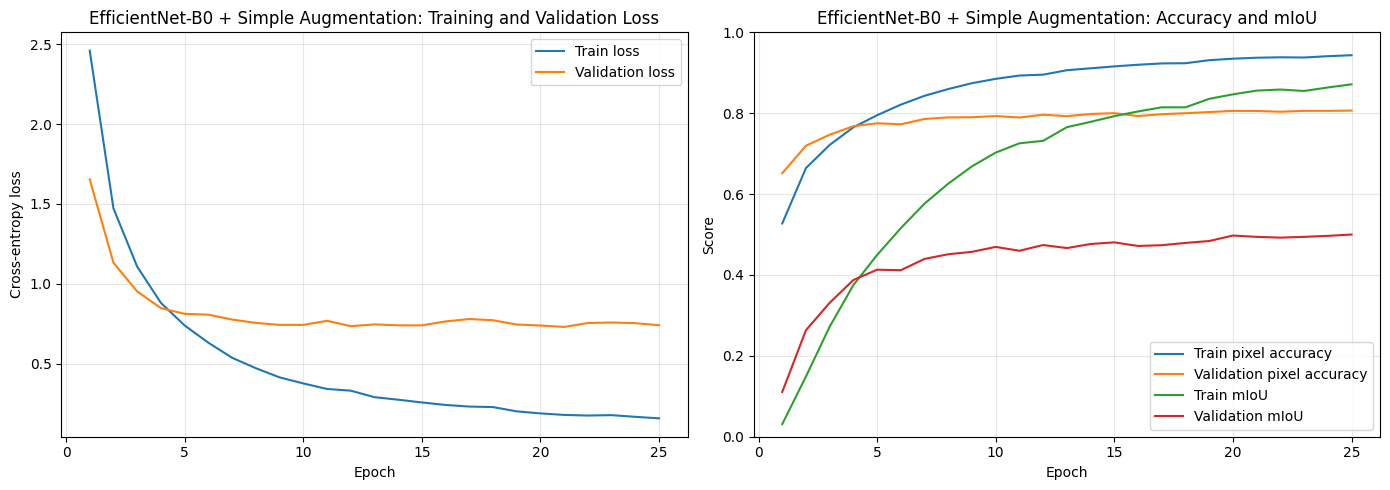

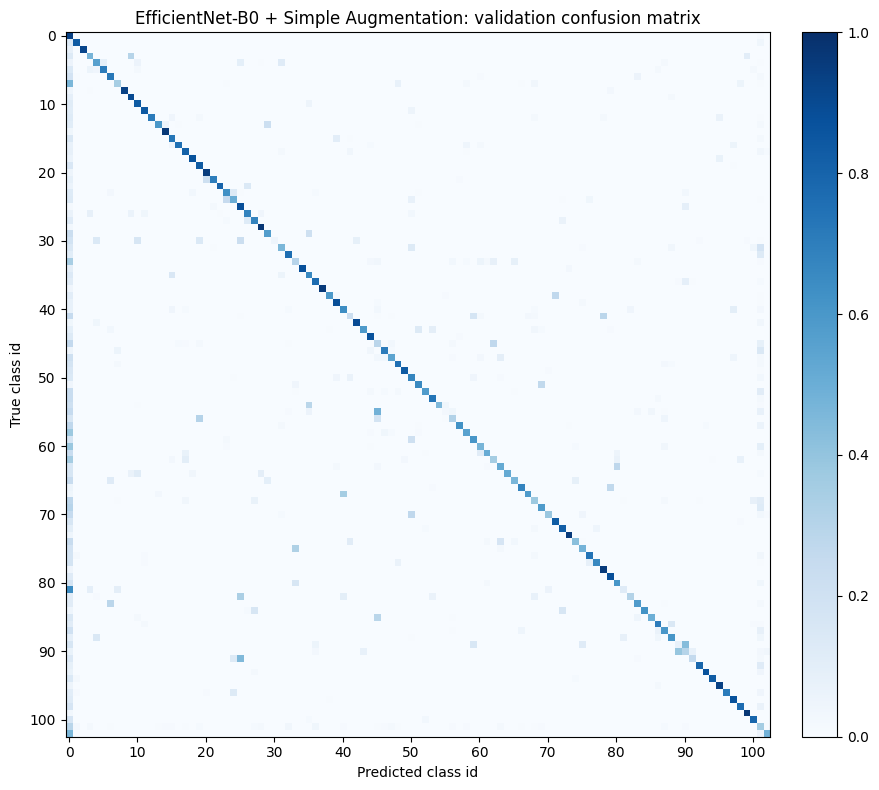

Best epoch: 25
Best validation mIoU: 0.49999927409286254
Test result: {'test_loss': 0.8921610589027404, 'test_accuracy': 0.7919446940104167, 'test_miou': 0.463908722757464}


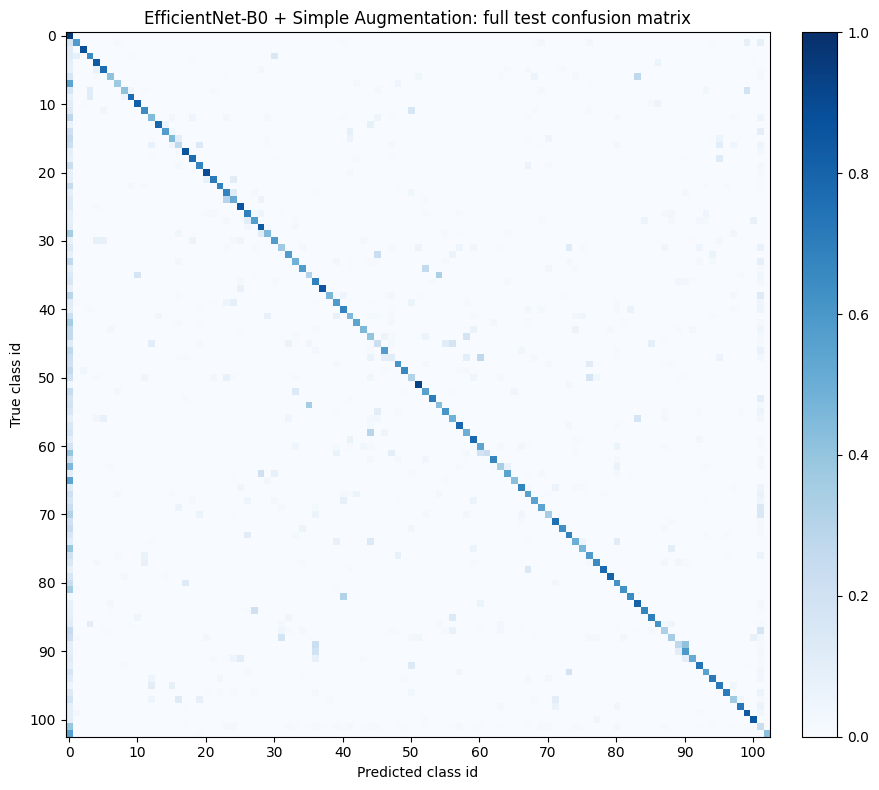

Best 10 classes by test IoU
  2 eels on rice                   IoU=0.8106 support=458314
 20 udon noodle                    IoU=0.7858 support=713089
 79 shrimp with chill source       IoU=0.7740 support=707674
 51 sweet and sour pork            IoU=0.7510 support=459207
 17 hamburger                      IoU=0.7488 support=1081756
 37 potage                         IoU=0.7447 support=470193
 13 croissant                      IoU=0.7170 support=635498
 78 fish-shaped pancake with bean jam IoU=0.7146 support=366508
  9 fried rice                     IoU=0.6974 support=549073
 18 pizza                          IoU=0.6733 support=957751
Worst 10 classes by test IoU
 47 salmon meuniere                IoU=0.0612 support=143770
 45 fried fish                     IoU=0.1015 support=255284
 44 teriyaki grilled fish          IoU=0.1386 support=171224
101 others                         IoU=0.1593 support=3425089
 50 sukiyaki                       IoU=0.1873 support=458709
 89 Japanese tofu and v

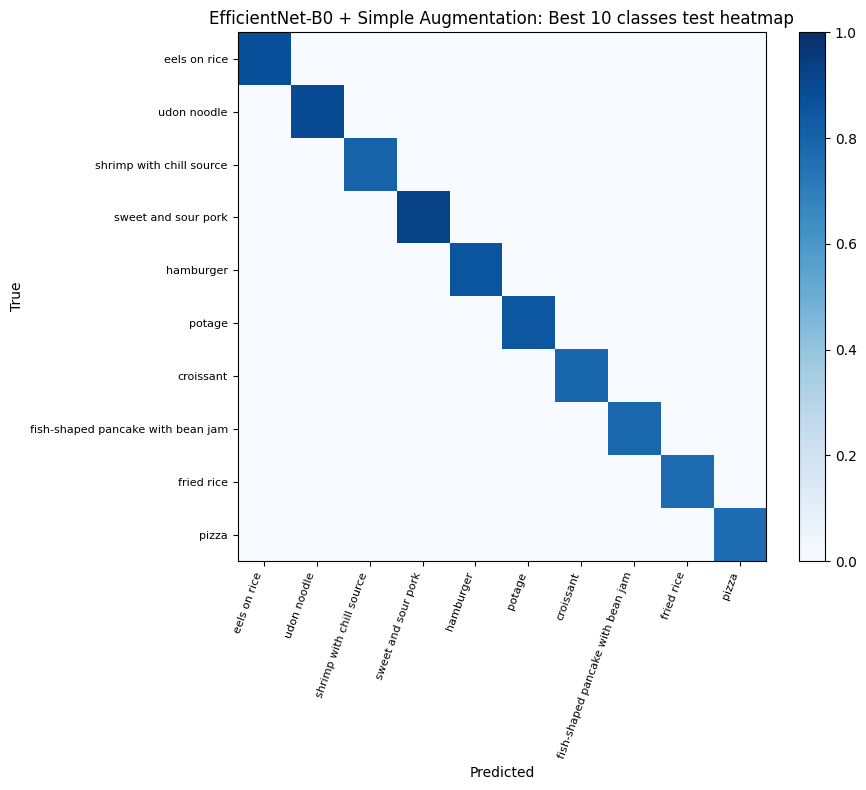

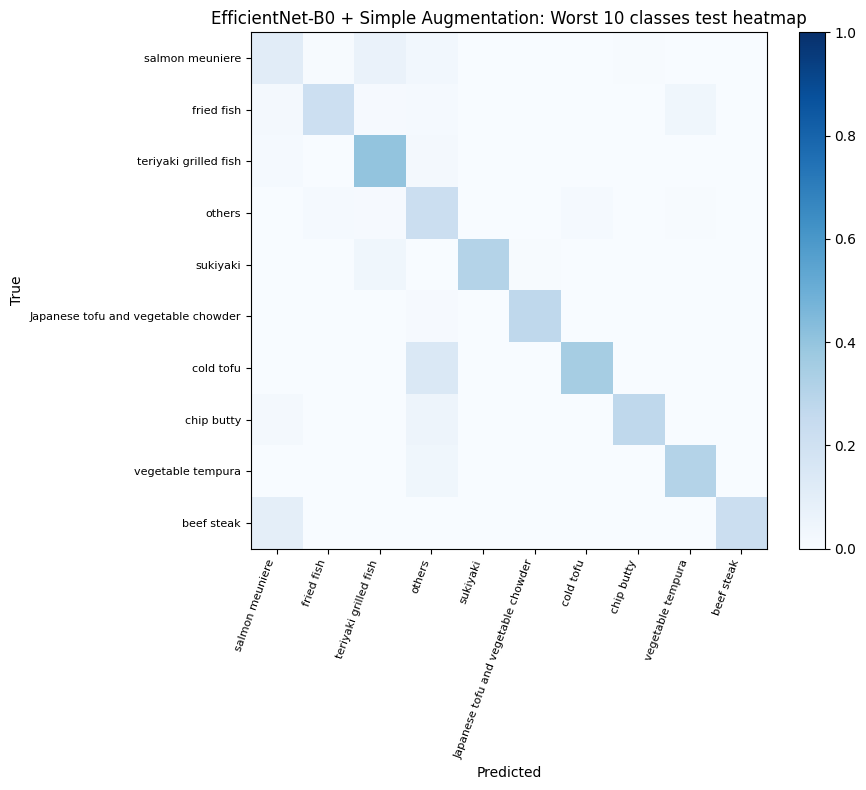

In [15]:
class EfficientNetAugmentedBaseline(nn.Module):
    def __init__(self, pretrained=True, dropout=0.25):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.encoder = efficientnet_b0(weights=weights).features
        self.classifier = nn.Sequential(
            nn.Dropout2d(dropout),
            nn.Conv2d(1280, NUM_CLASSES, kernel_size=1),
        )

    def forward(self, x):
        output_size = x.shape[-2:]
        logits = self.classifier(self.encoder(x))
        return F.interpolate(logits, size=output_size, mode="bilinear", align_corners=False)


EFFICIENTNET_AUG_CONFIG = {
    "learning_rate": 2e-4,
    "weight_decay": 5e-4,
    "dropout": 0.25,
    "early_stopping_patience": 5,
    "scheduler_patience": 2,
    "lr_factor": 0.5,
    "pretrained": True,
}


def train_efficientnet_augmented(config):
    seed_everything(SEED)
    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset, shuffle=False)
    test_loader = make_loader(test_dataset, shuffle=False)
    device = get_device()
    model = EfficientNetAugmentedBaseline(
        pretrained=config["pretrained"],
        dropout=config["dropout"],
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=config["lr_factor"],
        patience=config["scheduler_patience"],
    )
    loss_fn = nn.CrossEntropyLoss()
    checkpoint_path = BEST_MODEL_DIR / "EfficientNetB0_Augmented_best_model.pt"

    print("Training EfficientNet-B0 + Simple Augmentation")
    print(f"Config: {config}")
    print(f"Checkpoint: {checkpoint_path}")

    history = []
    best_miou = -1.0
    best_epoch = 0
    best_val_confusion = None
    stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_stats, _ = run_epoch(
            model,
            train_loader,
            loss_fn,
            device,
            optimizer,
            phase="EfficientNet-B0 augmented train",
        )
        val_loss, val_stats, val_confusion = run_epoch(
            model,
            val_loader,
            loss_fn,
            device,
            phase="EfficientNet-B0 augmented validation",
        )
        scheduler.step(val_stats["mean_iou"])

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_stats["pixel_accuracy"],
            "train_miou": train_stats["mean_iou"],
            "val_accuracy": val_stats["pixel_accuracy"],
            "val_miou": val_stats["mean_iou"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(row)

        if val_stats["mean_iou"] > best_miou:
            best_miou = val_stats["mean_iou"]
            best_epoch = epoch
            best_val_confusion = val_confusion.clone()
            stale_epochs = 0
            torch.save(
                {
                    "model_name": "EfficientNet-B0 + Simple Augmentation",
                    "epoch": best_epoch,
                    "validation_miou": best_miou,
                    "num_classes": NUM_CLASSES,
                    "image_width": WIDTH,
                    "image_height": HEIGHT,
                    "batch_size": BATCH_SIZE,
                    "max_epochs": MAX_EPOCHS,
                    "augmentation_config": AUGMENTATION_CONFIG,
                    "config": config,
                    "state_dict": model.state_dict(),
                },
                checkpoint_path,
            )
            print(f"Saved new best model: val_mIoU={best_miou:.4f}")
        else:
            stale_epochs += 1
            if stale_epochs >= config["early_stopping_patience"]:
                print(
                    "Early stopping after "
                    f"{config['early_stopping_patience']} epochs without validation mIoU improvement"
                )
                break

    plot_training_history(history, "EfficientNet-B0 + Simple Augmentation")
    if best_val_confusion is not None:
        plot_overall_confusion(best_val_confusion, "EfficientNet-B0 + Simple Augmentation: validation confusion matrix")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    test_loss, test_stats, test_confusion = run_epoch(
        model,
        test_loader,
        loss_fn,
        device,
        phase="EfficientNet-B0 augmented test",
    )
    test_result = {
        "test_loss": test_loss,
        "test_accuracy": test_stats["pixel_accuracy"],
        "test_miou": test_stats["mean_iou"],
    }
    print("Best epoch:", best_epoch)
    print("Best validation mIoU:", best_miou)
    print("Test result:", test_result)

    plot_overall_confusion(test_confusion, "EfficientNet-B0 + Simple Augmentation: full test confusion matrix")
    plot_best_worst_heatmaps(test_confusion, "EfficientNet-B0 + Simple Augmentation")

    return {
        "history": history,
        "best_epoch": best_epoch,
        "best_validation_miou": best_miou,
        "checkpoint_path": checkpoint_path,
        "test_result": test_result,
        "test_confusion": test_confusion,
    }


efficientnet_augmented_result = train_efficientnet_augmented(EFFICIENTNET_AUG_CONFIG)


### Result Interpretation

！！！请在此处解释分析结果！！！

When writing the analysis, compare this augmented EfficientNet-B0 result against the original EfficientNet-B0 baseline. Focus on whether validation/test mIoU improved, whether the train-validation gap became smaller, and whether the best/worst-class heatmaps show fewer systematic confusions.


---
## 7. Notes for the Next Step

This experiment is designed as a bridge between the plain EfficientNet-B0 baseline and a stronger paper-inspired EfficientNet U-Net architecture. If simple augmentation improves validation/test mIoU or reduces overfitting, it supports keeping augmentation in the final model. If the improvement is small, the next architectural change should focus on a decoder with skip connections rather than only more augmentation.


In [1]:
# Standalone no-background evaluation for EfficientNet_Data_Augmentation.ipynb
from pathlib import Path
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.std import tqdm
from torchvision.models import efficientnet_b0

NUM_CLASSES = 103
WIDTH = 384
HEIGHT = 320
BATCH_SIZE = 16
NUM_WORKERS = 0

ROOT = Path.cwd().resolve()
if not (ROOT / "Best_Model").exists():
    ROOT = Path("/content/drive/MyDrive/COMP9444/9444")

DATA_ROOT = ROOT / "UECFOODPIX" / "data" / "UECFoodPIX"
BEST_MODEL_DIR = ROOT / "Best_Model"

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class TestDataset(Dataset):
    def __init__(self):
        self.img_dir = DATA_ROOT / "test" / "img"
        self.mask_dir = DATA_ROOT / "test" / "mask"
        self.ids = sorted(p.stem for p in self.img_dir.glob("*.jpg"))
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        sid = self.ids[i]
        image = Image.open(self.img_dir / f"{sid}.jpg").convert("RGB").resize((WIDTH, HEIGHT), Image.Resampling.BILINEAR)
        mask = Image.open(self.mask_dir / f"{sid}.png").resize((WIDTH, HEIGHT), Image.Resampling.NEAREST)
        x = torch.from_numpy((np.asarray(image, dtype=np.float32) / 255.0).copy()).permute(2, 0, 1)
        x = (x - MEAN) / STD
        y = np.asarray(mask)
        if y.ndim == 3:
            y = y[..., 0]
        return x, torch.from_numpy(y.astype(np.int64, copy=True)).long()

class EffiAug(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = efficientnet_b0(weights=None).features
        self.classifier = nn.Sequential(nn.Dropout2d(0.25), nn.Conv2d(1280, NUM_CLASSES, 1))
    def forward(self, x):
        return F.interpolate(self.classifier(self.encoder(x)), size=x.shape[-2:], mode="bilinear", align_corners=False)

def update_confusion(cm, pred, target):
    pred = pred.detach().reshape(-1).cpu().long()
    target = target.detach().reshape(-1).cpu().long()
    valid = (target >= 0) & (target < NUM_CLASSES)
    encoded = target[valid] * NUM_CLASSES + pred[valid].clamp(0, NUM_CLASSES - 1)
    cm += torch.bincount(encoded, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)

def no_background_metrics(cm):
    cm = cm.double().numpy()
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    union = support + predicted - tp
    foreground = np.arange(1, NUM_CLASSES)
    iou = np.divide(tp, union, out=np.full_like(tp, np.nan), where=union > 0)
    return {
        "foreground_accuracy_no_background": float(tp[foreground].sum() / max(support[foreground].sum(), 1)),
        "mIoU_no_background": float(np.nanmean(iou[foreground])),
        "evaluated_foreground_classes": int(np.sum(~np.isnan(iou[foreground]))),
    }

def load_state(path, device):
    ckpt = torch.load(path, map_location=device)
    return ckpt.get("state_dict") or ckpt.get("model_state_dict") or ckpt

@torch.no_grad()
def evaluate():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(TestDataset(), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    model = EffiAug().to(device)
    model.load_state_dict(load_state(BEST_MODEL_DIR / "EfficientNetB0_Augmented_best_model.pt", device))
    model.eval()

    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)
    for x, y in tqdm(loader, desc="EfficientNet augmented no-bg test", ascii=True):
        x, y = x.to(device), y.to(device)
        update_confusion(cm, model(x).argmax(1), y)

    print(no_background_metrics(cm))

evaluate()

EfficientNet augmented no-bg test: 100%|##########| 63/63 [00:14<00:00,  4.23it/s]

{'foreground_accuracy_no_background': 0.5790001895491131, 'mIoU_no_background': 0.4602262790069452, 'evaluated_foreground_classes': 102}
